<h1><center>Lab 2</center></h1>

## Knapsack Problem
- $n$ objects, each has a value ($v$) and a weight ($w$)
- Objective: the knapsack to contain max value without exceeding max weight $W$
 - $x_i=1$ means object $i$ is selected
 - $x_i=0$ means object $j$ is not selected

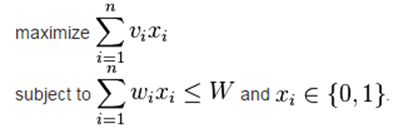


##	REQUIREMENTS
1.	Source code (notebook) needs to be documented.
2.	Algorithms have to be tested for several parameter values (sufficient to clearly determine performance).
3.	Experiments must be performed for all available problem instances and results compared for different parameter settings.
4.	Results of the experiments need to be saved in output files, indicating solution quality, parameter values used, number of runs.
5.	A report should capture the following: problem definition, algorithm used (name, steps/pseudocode), parameter setting, comparative results of experiments, discussion of results.


In [126]:
def load_data(file_name: str) -> "list[tuple[int, int]]":
    """
    Loads the knapsack items from a file.

    The file format is:
    - first line: number of items (n)
    - next n lines: item_id weight value
    - last line: capacity (handled by load_capacity)

    Returns:
        list of tuples (weight, value) for each item
    """
    weights_and_values = []
    with open(file_name) as f:
        lines = [line.strip() for line in f if line.strip()]

    n = int(lines[0])

    for i in range(1, n + 1):
        parts = lines[i].split()
        weight = int(parts[1])
        value = int(parts[2])
        weights_and_values.append((weight, value))

    return weights_and_values

In [127]:
def load_capacity(file_name: str) -> int:
    """
    Reads the knapsack capacity from the file.

    The capacity is stored in the last line of the instance file.
    """
    with open(file_name, "r") as f:
        lines = [line.strip() for line in f if line.strip()]
    return int(lines[-1])

In [128]:
import numpy as np

def generate_solution(n: int):
    """
        Generate solution of length n using binary encoding
        Input:
          n: int
        Output:
          sol: list
              - binary encoding solution
    """
    return list(map(int, np.random.randint(2, size=n)))


def total_weight(items: list, sol: list):
    """
        Total weight function
        Input:
          items: list
          sol: list
              - binary encoding solution
        Output:
          s: int
    """
    s = 0
    for i, (w,v) in enumerate(items):
        s += w * sol[i]
    return s

def total_value(items: list, sol: list):
    """
        Total value function
        Input:
          items: list
          sol: list
              - binary encoding solution
        Output:
          s: int
    """
    s = 0
    for i, (w,v) in enumerate(items):
        s += v * sol[i]
    return s

def is_valid(items: list, sol: list, capacity: int):
    """
     A solution is valid if its sum is lower or equal than capacity
     Input:
       items: list
       sol: list
           - binary encoding solution
       capacity: int
     Output:
        bool
    """
    return total_weight(items, sol) <= capacity


def generate_valid_solution(n: int, items: list, capacity: int):
    """
     A solution is valid if its total weight is lower than the capacity
     Input:
       n: int
       items: list
       capacity: int
     Output:
        sol: list
    """
    stop = False
    sol = []
    while not stop:
        sol = generate_solution(n)
        stop = is_valid(items, sol, capacity)
    return sol

In [129]:
from matplotlib import pyplot as plt

def random_hill_climbing(items, capacity):
    """
    Runs the random hill climbing algorithm and returns a solution after it finds the optimal solution or after 1000 evaluations.
    Input:
        items: list
        capacity: int
    Output:
        current : list
        best_value: int
        best_weight: int
    """
    n = len(items)
    current = generate_valid_solution(n, items, capacity)
    best_value = total_value(items, current)

    evaluations = 0
    while evaluations < 1000:
        candidate = current.copy()

        # choose random bit
        i = random.randint(0, n-1)

        # flip bit
        candidate[i] = 1 - candidate[i]

        if is_valid(items, candidate, capacity):
            candidate_value = total_value(items, candidate)

            if candidate_value >= best_value:
                current = candidate
                best_value = candidate_value

        evaluations += 1

    best_weight = total_weight(items, current)
    return current, best_value, best_weight

def random_hill_climbing_n_times(n: int, items: list, capacity: int):
    """
    Runs the random hill climbing algorithm n times and returns a list of the best solutions found.
    Input:
        n: int
            - number of times to run the algorithm
        items: list
        capacity: int
    Output:
        best_solutions: list
    """
    best_solutions = []
    for _ in range(n):
        best_solution, best_val, best_w = random_hill_climbing(items, capacity)
        best_solutions.append((best_solution, best_val, best_w))
    return best_solutions

import random

def steepest_ascent_hill_climbing(items: list, capacity: int):
    """
    Steepest Ascent Hill-Climbing for the knapsack problem.
    Input:
        items: list of tuples (weight, value)
        capacity: maximum allowed weight
    Output:
        best_solution: best binary solution found
        best_value: value of the best solution found
        best_weight: weight of the best solution found
    """

    n = len(items)
    evaluations = 0

    # global best found during the whole search
    best_solution = None
    best_value = -1
    best_weight = 0

    while evaluations < 1000:
        # Step 1: choose a random valid solution
        current = generate_valid_solution(n, items, capacity)
        current_value = total_value(items, current)
        current_weight = total_weight(items, current)

        # update global best if needed
        if current_value > best_value:
            best_solution = current.copy()
            best_value = current_value
            best_weight = current_weight

        improved = True

        while improved and evaluations < 1000:
            improved = False
            neighbors = []

            # Step 2: flip each bit one at a time
            for i in range(n):
                if evaluations >= 1000:
                    break

                candidate = current.copy()
                candidate[i] = 1 - candidate[i]   # flip bit
                evaluations += 1

                if is_valid(items, candidate, capacity):
                    candidate_value = total_value(items, candidate)
                    candidate_weight = total_weight(items, candidate)
                    neighbors.append((candidate, candidate_value, candidate_weight))

            # Step 3: choose the best improving neighbor
            if neighbors:
                max_neighbor_value = max(neighbors, key=lambda x: x[1])[1]

                if max_neighbor_value > current_value:
                    best_candidates = [x for x in neighbors if x[1] == max_neighbor_value]
                    chosen = random.choice(best_candidates)   # break ties randomly

                    current = chosen[0]
                    current_value = chosen[1]
                    current_weight = chosen[2]
                    improved = True

                    # update global best
                    if current_value > best_value:
                        best_solution = current.copy()
                        best_value = current_value
                        best_weight = current_weight

        # Step 4: if no improvement, restart from another random solution

    return best_solution, best_value, best_weight

def steepest_ascent_hill_climbing_n_times(runs: int, items: list, capacity: int):
    """
    Runs SAHC multiple times and returns the best solution from each run.
    """

    best_solutions = []

    for _ in range(runs):
        best_sol, best_val, best_w = steepest_ascent_hill_climbing(items, capacity)
        best_solutions.append((best_sol, best_val, best_w))

    return best_solutions

def plot_solutions(items: list, solution_list: "list[list]"):
    """
    Plots value and weight of the solutions in solution_list.
    Input:
        items: list
        solution_list: list
            - list of solutions
    Output:
        None
    """

    values = [total_value(items, sol) for sol in solution_list]
    weights = [total_weight(items,sol) for sol in solution_list]

    plt.plot(values, label="Value")
    plt.plot(weights, label="Weight")

    plt.xlabel("Iteration")
    plt.ylabel("Value / Weight")
    plt.title("Results")
    plt.legend()

    plt.show()

In [130]:
output_file = open("knapsack_results.txt", "w")
output_file.write("Instance,Best Value\n")
# output file used to store results

# runs - number of runs
runs_values = [10, 50, 100]

# running the algorithm for multiple sets of params and saving the results in a Markdown table
markdown_table = "| Instance | Runs | Best Value | Average Value |\n"
markdown_table += "|-----------------|----|-----|-------| \n"

def run_sahc_experiments(file_name: str):
    """
    Runs SAHC experiments for a given knapsack instance and saves the results in 'knapsack_results.txt'.
    """
    items = load_data(file_name)
    capacity = load_capacity(file_name)

    markdown_table = ""

    with open("knapsack_results.txt", "a") as output_file:

        for runs in runs_values:
            best_results = steepest_ascent_hill_climbing_n_times(runs, items, capacity)

            best = max(best_results, key=lambda x: x[1])
            average = sum(x[1] for x in best_results) / len(best_results)

            markdown_table += f"| {file_name} | {runs} | {best[1]} | {average:.2f} |\n"

            # save results to file
            output_file.write(f"{file_name},{runs},{best[1]},{average:.2f}\n")

    return markdown_table

markdown_table += run_sahc_experiments("knapsack-20.txt")
markdown_table += run_sahc_experiments("knapsack-200.txt")

print(markdown_table)

| Instance | Runs | Best Value | Average Value |
|-----------------|----|-----|-------| 
| knapsack-20.txt | 10 | 787 | 748.50 |
| knapsack-20.txt | 50 | 785 | 742.54 |
| knapsack-20.txt | 100 | 787 | 749.62 |
| knapsack-200.txt | 10 | 97617 | 96182.10 |
| knapsack-200.txt | 50 | 97732 | 96547.46 |
| knapsack-200.txt | 100 | 97542 | 96487.41 |



<h5>Problem definition</h5>
The Knapsack Problem consists of selecting a subset of items, each having a weight and a value, such that the total weight does not exceed a given capacity while the total value is maximized.


<h5>Algorithm used previously</h5>
Random Hill Climbing for Knapsack


1. Generate a random binary solution that satisfies the capacity constraint.
2. Choose a random bit to flip. If the flip leads to an equal or higher value, then set best-evaluated to the resulting string.
3. Repeats step 2 until optimum string has been found or until it has been evaluated 1000 times.
4. Keep the best solution found.


<h5>Algorithm used on assignment A2</h5>
Steepest Ascent Hill-Climbing


1. Choose a string at random. Call this string current-hilltop.
2. Going from left to right, systematically flip each bit in the string, one at a time, recording the best value of the resulting one-bit mutants.
3. If any resulting one-bit mutants give a value increase, then set current-hilltop to the one-bit mutant giving the highest value increase.
4. If there is no value increase, then save current-hilltop and go to step 1. Otherwise, go to step 2 with the new current-hilltop.
5. When a set number of function evaluations has been performed(here, each bit flip in step 2 is followed by a function evaluation), return the highest hilltop that was found.


<h5>Parameter setting</h5>
runs = number of times the algorithm is executed

runs ∈ {10, 50, 100}

<h5>Comparative results of experiments</h5>
See Markdown table.

<h5>Discussion of results</h5>
The experimental results show that increasing the number of runs leads to more stable average values. When only a small number of runs is used, the results may vary due to the random initial solution. However, as the number of runs increases, the algorithm tends to converge to similar local optima, resulting in consistent best and average values.
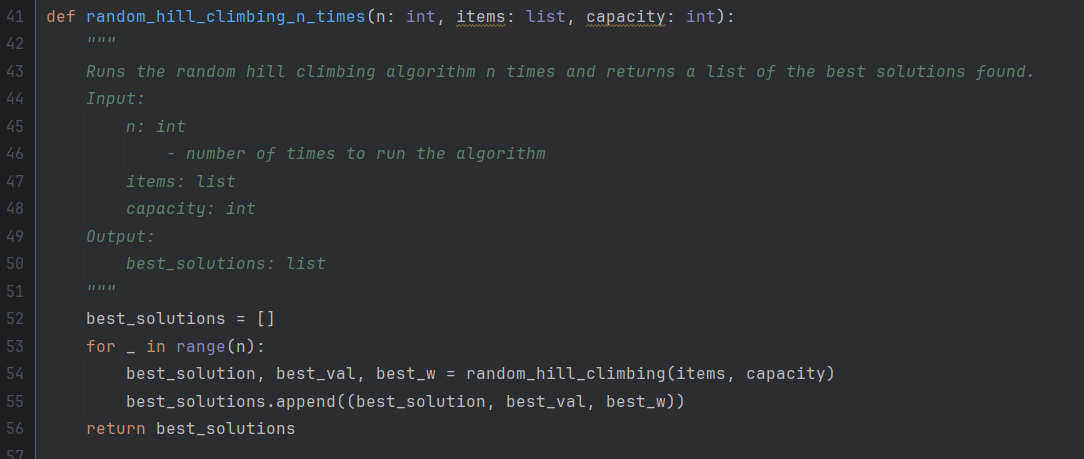
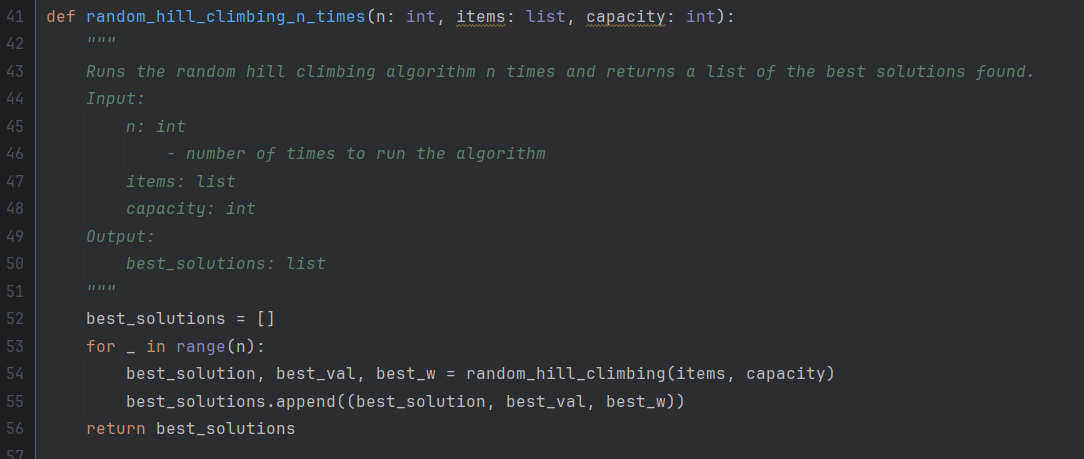

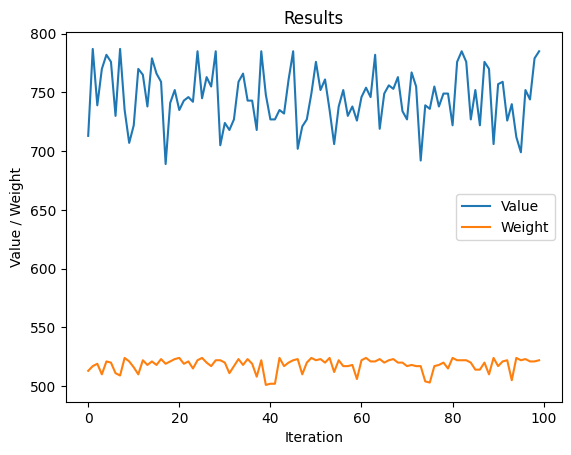

In [131]:
# we can showcase the evolution of a solution using a plot
file_name = "knapsack-20.txt"
items = load_data(file_name)
capacity = load_capacity(file_name)
sol = steepest_ascent_hill_climbing_n_times(runs_values, items, capacity)
plot_solutions(items, [x[0] for x in sol])